# RAG Evaluation

## Imports and Setup

In [2]:
import pandas as pd
from sentence_transformers import SentenceTransformer, CrossEncoder
from qdrant_client import QdrantClient
from qdrant_client.models import Filter, FieldCondition, MatchAny
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(".")

CHUNK_PATH     = BASE_DIR / "Results" / "chunk_data" / "rag_chunks.csv"
LABELS_PATH    = BASE_DIR / "Results" / "retriever_data" / "starter_query_pairs_template_labelled.csv"

model = SentenceTransformer("all-MiniLM-L6-v2")
vector_db = QdrantClient(path=str(BASE_DIR / "Results" / "retriever_data" / "qdrant_store"))
reranking_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
chunks = pd.read_csv(CHUNK_PATH)
labels = pd.read_csv(LABELS_PATH)

chunks.head(5)
labels.head(5)

c:\Users\owenl\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1974.90it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1672.73it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored w

,company,quarter,year,company_quarter,query,positive_chunk_id,hard_negative_chunk_id,notes
0,amazon,Q3,2025,amazon_Q3_2025,What were the key highlights from this earning...,amazon_Q3_2025_chunk_0,amazon_Q3_2025_chunk_6,NaN
1,amazon,Q3,2025,amazon_Q3_2025,What risks did management mention?,amazon_Q3_2025_chunk_0,amazon_Q3_2025_chunk_1,NaN
2,amazon,Q3,2025,amazon_Q3_2025,What was management's outlook for the next qua...,amazon_Q3_2025_chunk_0,amazon_Q3_2025_chunk_9,NaN
3,amazon,Q3,2025,amazon_Q3_2025,What did the company say about revenue growth?,amazon_Q3_2025_chunk_1,amazon_Q3_2025_chunk_2,NaN
4,amazon,Q3,2025,amazon_Q3_2025,What did the company say about margins or prof...,amazon_Q3_2025_chunk_1,amazon_Q3_2025_chunk_3,NaN


## Retrieve Functions (Bi-encoder & Cross Encoder)

In [3]:
def bi_encoder(query, model, db, top_k=5, filter_company=None, filter_quarter=None):
    """
    Retrieves top k chunks relevant to the query.
    Uses bi-encoder with metadata filtering first,
    then applies cross-encoder reranking on the retrieved set.
    """
    # Embed the query
    q_emb = model.encode([query], convert_to_numpy=True)[0].tolist()

    # Build metadata filter if provided
    conditions = []
    if filter_company:
        companies = filter_company if isinstance(filter_company, list) else [filter_company]
        conditions.append(FieldCondition(key="company", match=MatchAny(any=companies)))
    if filter_quarter:
        quarters = filter_quarter if isinstance(filter_quarter, list) else [filter_quarter]
        conditions.append(FieldCondition(key="quarter", match=MatchAny(any=quarters)))

    search_filter = Filter(must=conditions) if conditions else None

    # Bi-encoder retrieval with metadata filtering
    results = db.query_points(
        collection_name="chunks",
        query=q_emb,
        query_filter=search_filter,
        limit=top_k, # Set limit based on number of chunks in database (can be tuned); ideally more than top_k
        with_payload=True
    )

    return [
        {
            "chunk_id":   r.payload["chunk_id"],
            "company":    r.payload["company"],
            "quarter":    r.payload["quarter"],
            "score":      r.score,
            "chunk_text": r.payload["chunk_text"]
        }
        for r in results.points
    ]

def rerank(query, retrieved, model):
    """
    Reranks retrieved chunks using a cross-encoder.
    """
    pairs = [(query, chunk["chunk_text"]) for chunk in retrieved]
    rerank_scores = model.predict(pairs)

    for i, chunk in enumerate(retrieved):
        chunk["rerank_score"] = rerank_scores[i]

    reranked_chunks = sorted(retrieved, key=lambda x: x["rerank_score"], reverse=True)
    return reranked_chunks

## Retriever Evaluation Metric Functions


In [4]:
def precision_at_k(retrieved, relevant_ids, k):
    """
    Computes Precision@k for the retrieved chunks.
    """
    # Currently behaves like a binary function as we only identify 1 relevant chunk per query
    retrieved_ids = [chunk["chunk_id"] for chunk in retrieved[:k]]
    hits = sum(1 for rid in retrieved_ids if rid in relevant_ids)
    return hits / k # so this will return 1/k or 0 (for now)

def recall_at_k(retrieved, relevant_ids, k):
    """
    Computes Recall@k for the retrieved chunks.
    """
    # Currently also behaves like a binary function as we only identify 1 relevant chunk per query
    retrieved_ids = [chunk["chunk_id"] for chunk in retrieved[:k]]
    hits = sum(1 for rid in retrieved_ids if rid in relevant_ids)
    return hits / len(relevant_ids) if relevant_ids else 0.0

def MAP(retrieved, relevant_ids, k):
    """
    Computes Mean Average Precision (MAP) for the retrieved chunks.
    """
    total, relevant = 0, 0
    for i, chunk in enumerate(retrieved[:k], 1):
        if chunk["chunk_id"] in relevant_ids:
            relevant += 1
            total += relevant / i  # precision at position i
    return total / relevant if relevant > 0 else 0

def RR(retrieved, relevant_ids, k):
    """
    Computes Reciprocal Rank for a single query.
    Returns 1/rank of the first relevant chunk found in top k.
    """
    for i, chunk in enumerate(retrieved[:k], 1):
        if chunk["chunk_id"] in relevant_ids:
            return 1.0 / i
    return 0.0


## Evaluation 

In [5]:
k_values    = [1, 2, 3, 4, 5]
results = []

for k in k_values:
    for _, row in labels.iterrows():
        query            = row["query"]
        company          = row["company"]
        quarter          = row["quarter"]
        positive_id      = [row["positive_chunk_id"]]

        # Bi-encoder retrieval with metadata filtering
        retrieved_chunks = bi_encoder(query, model, vector_db, top_k=k, filter_company=company, filter_quarter=quarter)

        # Reranking with cross-encoder
        reranked_chunks = rerank(query, retrieved_chunks, reranking_model)

        results.append(
            {
                "k": k,
                "query": query,
                "company": company,
                "quarter": quarter,
                "positive_id": positive_id[0],
                # Bi-encoder metrics
                "bi_precision": precision_at_k(retrieved_chunks, positive_id, k),
                "bi_recall": recall_at_k(retrieved_chunks, positive_id, k),
                "bi_map": MAP(retrieved_chunks, positive_id, k),
                "bi_rr": RR(retrieved_chunks, positive_id, k),

                # Reranked metrics
                "rr_precision": precision_at_k(reranked_chunks, positive_id, k),
                "rr_recall": recall_at_k(reranked_chunks, positive_id, k),
                "rr_map": MAP(reranked_chunks, positive_id, k),
                "rr_rr": RR(reranked_chunks, positive_id, k)              
            }
        )

results_df = pd.DataFrame(results)
results_df

,k,query,company,quarter,positive_id,bi_precision,bi_recall,bi_map,bi_rr,rr_precision,rr_recall,rr_map,rr_rr
0,1,What were the key highlights from this earning...,amazon,Q3,amazon_Q3_2025_chunk_0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1,What risks did management mention?,amazon,Q3,amazon_Q3_2025_chunk_0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1,What was management's outlook for the next qua...,amazon,Q3,amazon_Q3_2025_chunk_0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1,What did the company say about revenue growth?,amazon,Q3,amazon_Q3_2025_chunk_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,What did the company say about margins or prof...,amazon,Q3,amazon_Q3_2025_chunk_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,5,What did the company say about revenue growth?,tesla,Q4,tesla_Q4_2025_chunk_0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
316,5,What did the company say about margins or prof...,tesla,Q4,tesla_Q4_2025_chunk_0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
317,5,What did management say about demand trends?,tesla,Q4,tesla_Q4_2025_chunk_0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
318,5,What did the company say about AI investments ...,tesla,Q4,tesla_Q4_2025_chunk_0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Cross Encoder Impact

In [6]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#    display(results_df)

improved = results_df[
    (results_df["rr_recall"]    > results_df["bi_recall"])    |
    (results_df["rr_precision"] > results_df["bi_precision"]) |
    (results_df["rr_rr"]        > results_df["bi_rr"])        |
    (results_df["rr_map"]       > results_df["bi_map"])
]
deproved = results_df[
    (results_df["rr_recall"]    < results_df["bi_recall"])    |
    (results_df["rr_precision"] < results_df["bi_precision"]) |
    (results_df["rr_rr"]        < results_df["bi_rr"])        |
    (results_df["rr_map"]       < results_df["bi_map"])
]
display(improved)
display(deproved)
print(f"Improved: {len(improved)} / {len(results_df)}")
print(f"Deproved: {len(deproved)} / {len(results_df)}")

,k,query,company,quarter,positive_id,bi_precision,bi_recall,bi_map,bi_rr,rr_precision,rr_recall,rr_map,rr_rr
68,2,What did the company say about margins or prof...,amazon,Q3,amazon_Q3_2025_chunk_1,0.500000,1.0,0.500000,0.500000,0.500000,1.0,1.0,1.0
75,2,What did the company say about revenue growth?,amazon,Q4,amazon_Q4_2025_chunk_1,0.500000,1.0,0.500000,0.500000,0.500000,1.0,1.0,1.0
76,2,What did the company say about margins or prof...,amazon,Q4,amazon_Q4_2025_chunk_1,0.500000,1.0,0.500000,0.500000,0.500000,1.0,1.0,1.0
82,2,What was management's outlook for the next qua...,apple,Q3,apple_Q3_2025_chunk_0,0.500000,1.0,0.500000,0.500000,0.500000,1.0,1.0,1.0
88,2,What were the key highlights from this earning...,apple,Q4,apple_Q4_2025_chunk_0,0.500000,1.0,0.500000,0.500000,0.500000,1.0,1.0,1.0
132,3,What did the company say about margins or prof...,amazon,Q3,amazon_Q3_2025_chunk_1,0.333333,1.0,0.500000,0.500000,0.333333,1.0,1.0,1.0
139,3,What did the company say about revenue growth?,amazon,Q4,amazon_Q4_2025_chunk_1,0.333333,1.0,0.500000,0.500000,0.333333,1.0,1.0,1.0
150,3,What did the company say about AI investments ...,apple,Q3,apple_Q3_2025_chunk_8,0.333333,1.0,0.333333,0.333333,0.333333,1.0,0.5,0.5
152,3,What were the key highlights from this earning...,apple,Q4,apple_Q4_2025_chunk_0,0.333333,1.0,0.500000,0.500000,0.333333,1.0,1.0,1.0
174,3,What did the company say about AI investments ...,meta,Q4,meta_Q4_2025_chunk_0,0.333333,1.0,0.333333,0.333333,0.333333,1.0,0.5,0.5


,k,query,company,quarter,positive_id,bi_precision,bi_recall,bi_map,bi_rr,rr_precision,rr_recall,rr_map,rr_rr
83,2,What did the company say about revenue growth?,apple,Q3,apple_Q3_2025_chunk_0,0.500000,1.0,1.000000,1.000000,0.500000,1.0,0.500000,0.500000
103,2,What concerns were raised during the Q&A?,meta,Q3,meta_Q3_2025_chunk_1,0.500000,1.0,1.000000,1.000000,0.500000,1.0,0.500000,0.500000
147,3,What did the company say about revenue growth?,apple,Q3,apple_Q3_2025_chunk_0,0.333333,1.0,1.000000,1.000000,0.333333,1.0,0.500000,0.500000
167,3,What concerns were raised during the Q&A?,meta,Q3,meta_Q3_2025_chunk_1,0.333333,1.0,1.000000,1.000000,0.333333,1.0,0.500000,0.500000
211,4,What did the company say about revenue growth?,apple,Q3,apple_Q3_2025_chunk_0,0.250000,1.0,1.000000,1.000000,0.250000,1.0,0.500000,0.500000
219,4,What did the company say about revenue growth?,apple,Q4,apple_Q4_2025_chunk_0,0.250000,1.0,0.333333,0.333333,0.250000,1.0,0.250000,0.250000
231,4,What concerns were raised during the Q&A?,meta,Q3,meta_Q3_2025_chunk_1,0.250000,1.0,1.000000,1.000000,0.250000,1.0,0.333333,0.333333
239,4,What concerns were raised during the Q&A?,meta,Q4,meta_Q4_2025_chunk_12,0.250000,1.0,0.500000,0.500000,0.250000,1.0,0.333333,0.333333
274,5,What was management's outlook for the next qua...,apple,Q3,apple_Q3_2025_chunk_0,0.200000,1.0,0.500000,0.500000,0.200000,1.0,0.333333,0.333333
275,5,What did the company say about revenue growth?,apple,Q3,apple_Q3_2025_chunk_0,0.200000,1.0,1.000000,1.000000,0.200000,1.0,0.500000,0.500000


Improved: 20 / 320
Deproved: 13 / 320


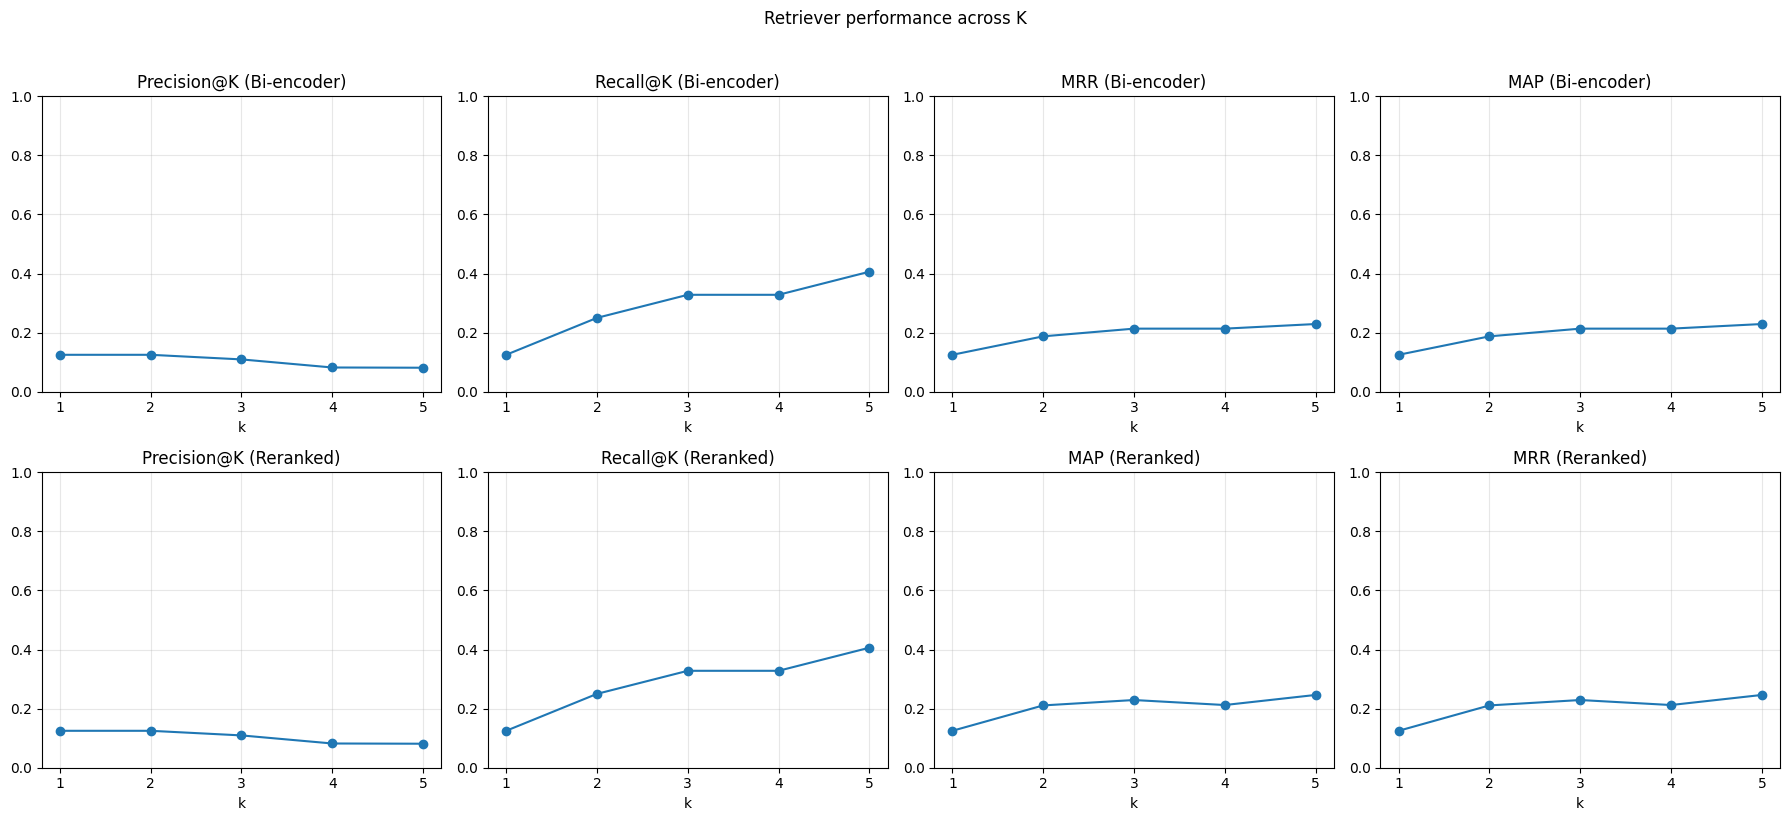

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

metrics = [
    ("bi_precision", "Precision@K (Bi-encoder)"),
    ("bi_recall",    "Recall@K (Bi-encoder)"),
    ("bi_rr",        "MRR (Bi-encoder)"),
    ("bi_map",       "MAP (Bi-encoder)"),
    ("rr_precision", "Precision@K (Reranked)"),
    ("rr_recall",    "Recall@K (Reranked)"),
    ("rr_map",       "MAP (Reranked)"),
    ("rr_rr",        "MRR (Reranked)")
    
]

for ax, (col, title) in zip(axes.flatten(), metrics):
    means = results_df.groupby("k")[col].mean()
    ax.plot(means.index, means.values, marker="o")
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.set_ylim(0, 1)
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)

plt.suptitle("Retriever performance across K", y=1.02)
plt.tight_layout()
plt.show()

### Evaluation by Company

In [8]:
company_metrics = results_df.groupby("company").agg(
    bi_precision = ("bi_precision", "mean"),
    bi_recall    = ("bi_recall",    "mean"),
    bi_map       = ("bi_map",        "mean"),
    bi_mrr       = ("bi_rr",        "mean"),
    rr_precision = ("rr_precision", "mean"),
    rr_recall    = ("rr_recall",    "mean"),
    rr_map       = ("rr_map",        "mean"),
    rr_mrr       = ("rr_rr",        "mean")
).round(4)

print(company_metrics.to_string())

         bi_precision  bi_recall  bi_map  bi_mrr  rr_precision  rr_recall  rr_map  rr_mrr
company                                                                                  
amazon         0.2119     0.5375  0.4175  0.4175        0.2119     0.5375  0.4713  0.4713
apple          0.0925     0.2875  0.1525  0.1525        0.0925     0.2875  0.1567  0.1567
meta           0.0829     0.2125  0.1625  0.1625        0.0829     0.2125  0.1323  0.1323
tesla          0.0308     0.1125  0.0425  0.0425        0.0308     0.1125  0.0588  0.0588


### Evaluation by Query

In [9]:
query_metrics = results_df.groupby("query").agg(
    bi_precision = ("bi_precision", "mean"),
    bi_recall    = ("bi_recall", "mean"),
    bi_map       = ("bi_map",     "mean"),
    bi_mrr       = ("bi_rr",     "mean"),
    rr_precision = ("rr_precision", "mean"),
    rr_recall    = ("rr_recall", "mean"),
    rr_map       = ("rr_map",     "mean"),
    rr_mrr       = ("rr_rr",     "mean")
).round(4)

print(query_metrics.to_string())

                                                            bi_precision  bi_recall  bi_map  bi_mrr  rr_precision  rr_recall  rr_map  rr_mrr
query                                                                                                                                       
What concerns were raised during the Q&A?                         0.0892      0.225   0.175   0.175        0.0892      0.225  0.1062  0.1062
What did management say about demand trends?                      0.0050      0.025   0.005   0.005        0.0050      0.025  0.0250  0.0250
What did the company say about AI investments or strategy?        0.0442      0.175   0.055   0.055        0.0442      0.175  0.0675  0.0675
What did the company say about margins or profitability?          0.0888      0.300   0.130   0.130        0.0888      0.300  0.1925  0.1925
What did the company say about revenue growth?                    0.1604      0.475   0.275   0.275        0.1604      0.475  0.2583  0.2583
What risks di

### Failures

In [10]:
# Filter rows where positive chunk was not retrieved at all (recall = 0 at max K)
max_k = max(k_values)
failures = results_df[
    (results_df["k"] == max_k) & (results_df["bi_recall"] == 0.0)
][["company", "query", "positive_id"]]

if len(failures) == 0:
    print("No failures — positive chunk retrieved in all cases at K=", max_k)
else:
    print(f"{len(failures)} failure(s) at K={max_k}:\n")
    print(failures.to_string(index=False))  

38 failure(s) at K=5:

company                                                      query            positive_id
 amazon                  What concerns were raised during the Q&A? amazon_Q3_2025_chunk_2
 amazon        What was management's outlook for the next quarter? amazon_Q4_2025_chunk_1
 amazon               What did management say about demand trends? amazon_Q4_2025_chunk_3
 amazon What did the company say about AI investments or strategy? amazon_Q4_2025_chunk_0
 amazon                  What concerns were raised during the Q&A? amazon_Q4_2025_chunk_2
  apple      What were the key highlights from this earnings call?  apple_Q3_2025_chunk_0
  apple                         What risks did management mention?  apple_Q3_2025_chunk_0
  apple               What did management say about demand trends?  apple_Q3_2025_chunk_0
  apple                  What concerns were raised during the Q&A? apple_Q3_2025_chunk_10
  apple                         What risks did management mention?  apple_Q4_